In [29]:
# Capstone -- function 3 (3D)

import numpy as np
import matplotlib.pyplot as plt

# Delaunay: convex-hull membership check for the proposal.
# ConvexHull: hull volume, to quantify how loose the bounding box is.
from scipy.spatial import Delaunay, ConvexHull

from bayes_tools import (
    load_collected, save_proposal,
    fitting,
    normalize, initial_bounds, validate_bounds_consistency,
    generate_next_point, ucb_acquisition,
    append_observations, compute_iteration_diagnostics,
    fit_gp, get_length_scales, loo_predictions,
    backtest_acquisitions, print_backtest_summary,
)
from viz_tools import (
    plot_nd_slices, plot_loo_calibration,
    plot_acquisition_backtest,
    plot_convergence, plot_acquisition_decay, plot_uncertainty_shrinkage,
    plot_step_distance,
)

# Function 3

3D, 18 observations (15 initial + weeks 2–4). We propose with `ucb`, `KAPPA = 0.5`, on the observed bounding box, with the search restricted to `x2` as kappa == 1.0 is now performing worse 


## Why only x2 is searched

Length-scales are `[10.0, 10.0, 0.131]`: `x0` and `x1` are pinned, so the GP sees signal only in `x2`. The acquisition is flat along the pinned axes, so left free it parks them on a box edge outside the data cloud. We hold them at the incumbent `[0.4926, 0.6116]` and scan `x2`.

This is now backed by data rather than just the GP, which matters because all three collected points sit on one `x0`/`x1` line and I was worried the pinning was self-reinforcing. Over pairs with similar `x2` (|Δx2| ≤ 0.06), mean |Δy| is **0.0159** when `x0`/`x1` are far apart (n=9) versus **0.0202** when close (n=5), against a `y` std of 0.0793. Moving them a long way changes `y` no more than staying put. Small n, but independent of the length-scales.

- LOO calibration: 16/18 points inside their own 95% interval.

In [30]:
X_initial = np.load("initial_data/function_3/initial_inputs.npy")
y_initial = np.load("initial_data/function_3/initial_outputs.npy")
n_initial = len(y_initial)
D = X_initial.shape[1]

assert D == 3, f"Expected a 3D problem, got {D}D input -- check the loaded file."

# Loaded once and never modified.
new_X = np.empty((0, D))
new_y = np.empty((0,))

## Update this once per week

Nothing to edit here — the collected observations come from `weekly_data/function_3/`. Run `record_results.py` first so last week's result is in place.

In [31]:
# My collected observations, from weekly_data/function_3/. I run
# record_results.py before opening this notebook so the results are already
# there. pending_X holds a proposal with no result yet; it never reaches the
# model.
#
# Provenance of the collected points, oldest first:
#   - week 2
#   - week 3 -- the max_variance proposal

new_X, new_y, pending_X = load_collected(3, D)

print("observations collected so far:", len(new_y))
print("latest y: %.6f | best before it: %.6f (change %+.6f)"
      % (new_y[-1], max(y_initial.max(), new_y[0]),
         new_y[-1] - max(y_initial.max(), new_y[0])))


weekly store: 4 resulted observation(s), 1 pending proposal [0.492581 0.611593 0.508904]
  NOTE the pending row will be REPLACED when this notebook saves its proposal
observations collected so far: 4
latest y: -0.028332 | best before it: -0.034835 (change +0.006504)


## Build the full dataset (initial + everything collected so far)

In [32]:
X, y = append_observations(X_initial, y_initial, new_X, new_y)

print("X_initial shape:", X_initial.shape, "| y_initial shape:", y_initial.shape)
print("new_X shape:     ", new_X.shape, "| new_y shape:     ", new_y.shape)
print("combined X shape:", X.shape, "| combined y shape:", y.shape)

print("\nX range per dimension:")
print("  min:", X.min(axis=0))
print("  max:", X.max(axis=0))
print("y range:", y.min(), "to", y.max())

# The project-standard padded bounds, kept for comparison against the box
# bounds we actually use.
bounds_standard = initial_bounds(X_initial, pad_fraction=1.0, lower_limit=0.0,
                        upper_limit=1.0)
validate_bounds_consistency(X, bounds_standard)

# We search the observed bounding box instead, so no coordinate can exceed the
# range already seen on its own axis. This is the box, not the hull, so it
# constrains extrapolation without eliminating it -- the proposal cell checks
# hull membership separately. Worth reverting once the GP has reason to prefer a
# direction along x0/x1, or the search can never leave the initial footprint.
bounds_box = np.column_stack([X.min(axis=0), X.max(axis=0)])
validate_bounds_consistency(X, bounds_box)

bounds = bounds_box

print("\nstandard bounds (pad_fraction=1.0):\n", np.round(bounds_standard, 4))
print("\nobserved bounding box (USED THIS WEEK):\n", np.round(bounds_box, 4))

print("\nfraction of each standard-bounds axis actually covered by data:")
frac = 1.0
for d in range(D):
    f = (X[:, d].max() - X[:, d].min()) / (bounds_standard[d, 1] - bounds_standard[d, 0])
    frac *= f
    print(f"  x{d}: {f:.1%}")
print(f"  -> {frac:.1%} of the standard box by volume; the rest is extrapolation")

# How loose is the box as a stand-in for where the data actually is? In 3D with
# few points the cloud is nearly all surface, so the box overstates it.
hull = Delaunay(X)
box_volume = float(np.prod(bounds_box[:, 1] - bounds_box[:, 0]))
try:
    ch_volume = ConvexHull(X).volume
    print(f"\nbounding box volume: {box_volume:.5f} | true convex hull volume: {ch_volume:.5f}"
          f" ({ch_volume / box_volume:.1%} of the box)")
except Exception as exc:  # degenerate point set -- not fatal, just skip
    print("\nconvex hull volume unavailable:", exc)

xi_frac = 0.01 / (y.max() - y.min())
print(f"\nxi=0.01 is {xi_frac:.2%} of the y spread "
      f"-> {'scaling NOT needed' if 0.001 <= xi_frac <= 0.1 else 'CONSIDER y-scaling'}")

X_initial shape: (15, 3) | y_initial shape: (15,)
new_X shape:      (4, 3) | new_y shape:      (4,)
combined X shape: (19, 3) | combined y shape: (19,)

X range per dimension:
  min: [0.04680895 0.21991724 0.06608864]
  max: [0.96599485 0.94135983 0.99088187]
y range: -0.3989255131463011 to -0.028331549686210305

standard bounds (pad_fraction=1.0):
 [[0. 1.]
 [0. 1.]
 [0. 1.]]

observed bounding box (USED THIS WEEK):
 [[0.0468 0.966 ]
 [0.2199 0.9414]
 [0.0661 0.9909]]

fraction of each standard-bounds axis actually covered by data:
  x0: 91.9%
  x1: 72.1%
  x2: 92.5%
  -> 61.3% of the standard box by volume; the rest is extrapolation

bounding box volume: 0.61327 | true convex hull volume: 0.21630 (35.3% of the box)

xi=0.01 is 2.70% of the y spread -> scaling NOT needed


## Backtest acquisition functions

Splitting the data into a seed set and a held-out candidate set, then seeing which config would have picked the best candidate. Free, and worth roughly what it costs.

**Expect `max_variance` last, and expect that not to matter.** The metric rewards whatever ranks closest to the posterior mean, so a pure uncertainty-seeker is penalised by construction. This table can't be used to argue against the choice above. The ordering among the other configs is weak too — the top few sit within about 0.014 with near-identical medians.

One thing specific to this notebook: these numbers move with the bounds, because the bounds set the input normalisation the GP is fit on. They won't match a week run on padded bounds, so don't compare across bounds choices.

[fitting: acquisition backtest, 50 splits] 113 warnings held back, 6 distinct:
    35 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
    34 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
    30 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
    11 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
     2 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at lower bound 0.01
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at lower bound 0.01
      config |  mean regret |  median regret |  mean picked y
-------------------------------------------------------------
     exploit |      0.02947 |          0.015 |       -0.06141
    pi_xi001 |      0.03954 |        0.02158 |       -0.07148
      ucb_k1 |      0.04675 |        0.02826 |       -0.07869
    ei_xi001 |      0.05739 |        0.07749 |       -0.08932
      ucb_k5 |      0.09911 |        

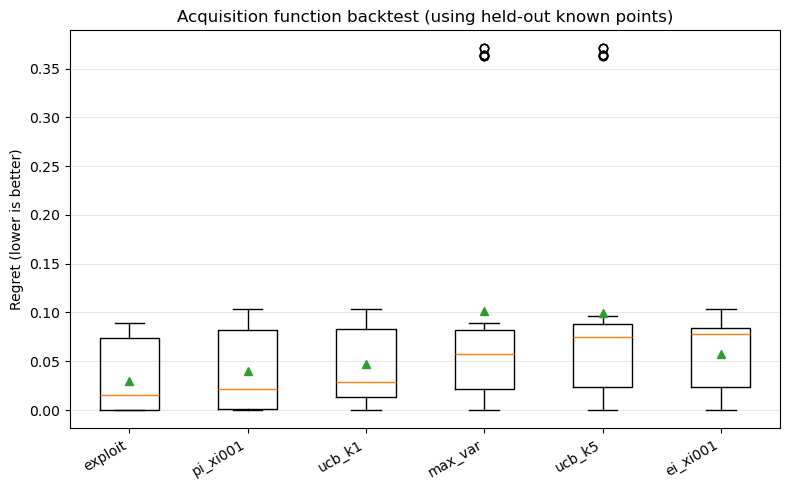

In [33]:
# No y-scaling here, so any xi below is in raw y-units.
backtest_configs = [
    {"name": "ei_xi001", "acquisition": "ei",  "xi": 0.01},
    {"name": "pi_xi001", "acquisition": "pi",  "xi": 0.01},
    {"name": "ucb_k1",   "acquisition": "ucb", "kappa": 1.0},
    {"name": "ucb_k5",   "acquisition": "ucb", "kappa": 5.0},
    {"name": "exploit",  "acquisition": "exploit"},
    {"name": "max_var",  "acquisition": "max_variance"},
]

with fitting("acquisition backtest, 50 splits"):
    backtest_results = backtest_acquisitions(
        X, y, bounds, backtest_configs,
        n_repeats=50, seed_frac=0.5, maximize=True,
        gp_kwargs={"n_restarts_optimizer": 15}, random_state=0,
    )

print_backtest_summary(backtest_results)

plot_acquisition_backtest(backtest_results)
plt.show()

## Sensitivity check: which dimensions actually matter

Per-dimension length-scales. Short means the function varies quickly along that axis; pinned at the upper limit means the GP sees it as close to irrelevant.

This cell is load-bearing for the whole approach — the proposal restricts its search to whichever dimensions come back non-pinned, and warns if that stops being exactly one. It's also why the `x0` and `x1` panels in the slice plot look flat.

In [34]:
# PINNED and incumbent are defined once here and reused below. The proposal used
# to depend on incumbent being set in an evidence-only cell, which made that
# cell load-bearing by accident.
PINNED = 10.0  # fit_gp's default length_scale_bounds upper limit

with fitting("shared GP for the sensitivity check"):
    gp_check = fit_gp(X, y, bounds, n_restarts_optimizer=20, random_state=0)

length_scales = get_length_scales(gp_check)
incumbent = X[np.argmax(y)]

for dim, ls in sorted(enumerate(length_scales), key=lambda t: t[1]):
    pinned = ls >= 0.999 * PINNED
    tag = "<- PINNED, looks irrelevant" if pinned else (
        "(most sensitive)" if ls == length_scales.min() else "")
    print(f"x{dim}: length_scale = {ls:8.3f} {tag}")

informative = [d for d, ls in enumerate(length_scales) if ls < 0.999 * PINNED]
print("\ndimensions the GP currently treats as informative:", informative)
print(f"incumbent (best observed point): {np.round(incumbent, 4)}  y = {y.max():.4f}")

[fitting: shared GP for the sensitivity check] 2 warnings held back, 2 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
x2: length_scale =    0.143 (most sensitive)
x0: length_scale =   10.000 <- PINNED, looks irrelevant
x1: length_scale =   10.000 <- PINNED, looks irrelevant

dimensions the GP currently treats as informative: [2]
incumbent (best observed point): [0.4926 0.6116 0.8678]  y = -0.0283


## Exploration status along x2, and choosing kappa

Two questions, both answered from data already collected.

**Is there unresolved structure left along x2?** Each inter-point gap against the fitted `x2` length-scale, in raw units. A gap wider than the length-scale is one the GP can't interpolate — that's where hidden structure survives, and it's where week 4's peak was. Gaps below it mostly confirm what the GP already believes.

**How much exploration weight?** `kappa` is swept on the *restricted line* rather than with `compare_kappa_proposals`, which searches the full box — with the acquisition flat along `x0`/`x1` an unrestricted sweep returns arbitrary values there and tells us nothing. What bounds the usable range is the `kappa` at which the proposal jumps mode, not saturation.

In [35]:
# The length-scale comes back in normalised units, so convert to raw x2 units
# before comparing it against the gaps between observations.
ls_x2_raw = get_length_scales(gp_check)[2] * (bounds[2, 1] - bounds[2, 0])

order = np.argsort(X[:, 2])
xs, ys = X[order, 2], y[order]
gaps = [(b - a, a, b, ya, yb)
        for a, b, ya, yb in zip(xs[:-1], xs[1:], ys[:-1], ys[1:])]

print(f"x2 length-scale: {ls_x2_raw:.4f} in raw x2 units")
print(f"\n{'gap':>7} | {'x2 span':>15} | {'y at each end':>19} | {'|dy|':>7} | verdict")
print("-" * 74)
for g, a, b, ya, yb in sorted(gaps, reverse=True)[:5]:
    verdict = "UNRESOLVED (> ls)" if g > ls_x2_raw else "interpolable (< ls)"
    print(f"{g:7.4f} | {a:6.3f} -> {b:6.3f} | {ya:+9.4f} /{yb:+9.4f} |"
          f" {abs(yb - ya):7.4f} | {verdict}")

largest = max(g[0] for g in gaps)
print(f"\nlargest gap {largest:.4f} / length-scale {ls_x2_raw:.4f} = {largest / ls_x2_raw:.2f}")
print("  week 4: ratio 1.35, and that gap hid a peak ~0.08 above both its brackets.")
print(f"  -> {'structure may remain; exploration still justified'
        if largest > ls_x2_raw else
        'no gap exceeds the length-scale; pure exploration has little left to find'}")

# --- the GP's own view of the line, so the modes are visible ---------------
print("\nGP posterior along x2 (x0/x1 held at the incumbent):")
print(f"{'x2':>7} | {'GP mean':>9} | {'GP std':>7} | {'nearest observed y':>19}")
for v in (0.10, 0.34, 0.46, 0.57, 0.62, 0.67, 0.77, 0.84, 0.86, 0.92, 0.99):
    p = incumbent.copy()
    p[2] = v
    m, s = gp_check.predict(normalize(p.reshape(1, -1), bounds), return_std=True)
    j = int(np.argmin(np.abs(X[:, 2] - v)))
    print(f"{v:7.2f} | {m[0]:+9.4f} | {s[0]:7.4f} | {y[j]:+9.4f} (x2={X[j, 2]:.3f})")

# --- kappa sweep, restricted to the informative axis -----------------------
scan_k = np.tile(incumbent, (3000, 1))
scan_k[:, 2] = np.linspace(bounds[2, 0], bounds[2, 1], 3000)
scan_k_norm = normalize(scan_k, bounds)
mu_k, sd_k = gp_check.predict(scan_k_norm, return_std=True)

print(f"\n{'kappa':>6} | {'x2':>7} | {'pred mean':>10} | {'pred std':>9} |"
      f" {'d(incumbent x2)':>16} | new best?")
print("-" * 76)
prev = None
for k in (0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0):
    j = int(np.argmax(ucb_acquisition(scan_k_norm, gp_check, kappa=k, maximize=True)))
    jump = "" if prev is None or abs(scan_k[j, 2] - prev) < 0.05 else "   <- MODE JUMP"
    print(f"{k:6.1f} | {scan_k[j, 2]:7.4f} | {mu_k[j]:+10.4f} | {sd_k[j]:9.4f} |"
          f" {abs(scan_k[j, 2] - incumbent[2]):16.4f} |"
          f" {'YES' if mu_k[j] > y.max() else 'no':>9}{jump}")
    prev = scan_k[j, 2]

# Committed choice, reused by the proposal and the slice plot. The diagnostics
# replay deliberately differs -- see that cell.
KAPPA = 0.5
print(f"\nusing kappa = {KAPPA} (dimensionless; y-scaling would not affect it)")
print("  chosen just below the mode jump, close to pure exploit but keeping a")
print("  variance term. Incumbent to beat: %.5f" % y.max())

x2 length-scale: 0.1320 in raw x2 units

    gap |         x2 span |       y at each end |    |dy| | verdict
--------------------------------------------------------------------------
 0.1086 |  0.458 ->  0.567 |   -0.0480 /  -0.0568 |  0.0088 | interpolable (< ls)
 0.1030 |  0.567 ->  0.670 |   -0.0568 /  -0.1101 |  0.0533 | interpolable (< ls)
 0.1008 |  0.670 ->  0.771 |   -0.1101 /  -0.1180 |  0.0080 | interpolable (< ls)
 0.0831 |  0.066 ->  0.149 |   -0.0364 /  -0.0942 |  0.0578 | interpolable (< ls)
 0.0749 |  0.344 ->  0.418 |   -0.0469 /  -0.0564 |  0.0095 | interpolable (< ls)

largest gap 0.1086 / length-scale 0.1320 = 0.82
  week 4: ratio 1.35, and that gap hid a peak ~0.08 above both its brackets.
  -> no gap exceeds the length-scale; pure exploration has little left to find

GP posterior along x2 (x0/x1 held at the incumbent):
     x2 |   GP mean |  GP std |  nearest observed y
   0.10 |   -0.0545 |  0.0218 |   -0.0364 (x2=0.066)
   0.34 |   -0.0411 |  0.0120 |   -0.0348 

## Propose the next point: UCB along the informative dimension

Three steps:

1. Re-confirm the GP still treats exactly one dimension as informative. The restricted construction is only valid while that holds, so it's recomputed rather than assumed.
2. Run UCB unconstrained inside the box for reference. Its `x0`/`x1` are arbitrary — that's the thing being demonstrated, not a bug.
3. Scan `x2` finely with `x0`/`x1` held at the incumbent and take the argmax. Same acquisition and `KAPPA` as step 2, so the two are comparable; a large disagreement on `x2` would mean the flat-axis assumption has broken down.

Then the safety checks: per-axis range, convex-hull membership, and which observations bracket the proposal.

In [36]:
# All the fitting first, so warnings can't land in the middle of the three-step
# output. PINNED comes from the sensitivity cell, KAPPA from the sweep.
with fitting("unconstrained UCB, for reference"):
    x_unconstrained, gp = generate_next_point(
        X, y, bounds,
        acquisition="ucb",
        kappa=KAPPA,
        maximize=True,
        n_restarts=40,
        random_state=0,
    )

# --- 1. Which dimensions does the GP actually use? -------------------------
informative = [d for d, ls in enumerate(get_length_scales(gp_check)) if ls < 0.999 * PINNED]
flat = [d for d in range(D) if d not in informative]
print("informative dimensions:", informative, "| flat (pinned) dimensions:", flat)

if len(informative) != 1:
    print("\n*** The 'one informative axis' assumption no longer holds. ***")
    print("Re-read the header: the restricted-search construction below was")
    print("justified by exactly one non-pinned dimension. Reconsider before using.")

# --- 2. Unconstrained UCB within the box, for reference --------------------
# (fitted above, before any printing)
mu_u, sd_u = gp.predict(normalize(x_unconstrained.reshape(1, -1), bounds), return_std=True)
print(f"\nunconstrained ucb(kappa={KAPPA}): {np.round(x_unconstrained, 4)}"
      f"  mean={mu_u[0]:+.4f} std={sd_u[0]:.4f}")
print(f"  in convex hull of the data: {hull.find_simplex(x_unconstrained) >= 0}")
print("  (its x0/x1 are arbitrary -- the acquisition is flat along them)")

# --- 3. The point actually proposed ---------------------------------------
DIM = informative[0] if len(informative) == 1 else int(np.argmin(get_length_scales(gp_check)))
scan = np.tile(incumbent, (3000, 1))
scan[:, DIM] = np.linspace(bounds[DIM, 0], bounds[DIM, 1], 3000)
scan_norm = normalize(scan, bounds)
acq_vals = ucb_acquisition(scan_norm, gp, kappa=KAPPA, maximize=True)

x_next = scan[int(np.argmax(acq_vals))]
mu, sigma = gp.predict(normalize(x_next.reshape(1, -1), bounds), return_std=True)

print(f"\n--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print("x_next:", np.round(x_next, 6))
print(gp.kernel_)
print(f"GP predicted mean: {mu[0]:.4g}, predicted std: {sigma[0]:.4g}")
print(f"incumbent y: {y.max():.5f}  -> predicted improvement: {mu[0] - y.max():+.5f}"
      f" ({'a NEW BEST if it holds' if mu[0] > y.max() else 'below the incumbent'})")

drift = abs(x_next[DIM] - x_unconstrained[DIM])
print(f"\nx{DIM} agreement between constrained and unconstrained: "
      f"{x_next[DIM]:.4f} vs {x_unconstrained[DIM]:.4f} (drift {drift:.4f})")
if drift > 0.05:
    print("*** They disagree. The flat-axis assumption may have broken down -- check before submitting. ***")

# --- Safety checks --------------------------------------------------------
on_edge = [d for d in range(D)
           if np.isclose(x_next[d], bounds[d, 0]) or np.isclose(x_next[d], bounds[d, 1])]
outside = [d for d in range(D) if not (X[:, d].min() <= x_next[d] <= X[:, d].max())]
print("\ndimensions where x_next sits on a bound:", on_edge or "none")
print("dimensions where x_next is outside the observed data range:", outside or "none")

in_hull = bool(hull.find_simplex(x_next) >= 0)
print(f"\nx_next inside the CONVEX HULL of the observations: {in_hull}")
if not in_hull:
    print("*** x_next is within range on every axis but outside the data cloud. ***")
    print("    That is still extrapolation. Consider moving the flat coordinates")
    print("    further toward the centre of the data before submitting.")

# How far is this from the nearest thing already measured? An exploitation-
# leaning proposal sitting almost on top of an observation buys very little.
d_near = float(np.min(np.abs(X[:, DIM] - x_next[DIM])))
print(f"\nnearest existing observation along x{DIM}: {d_near:.4f} away"
      f" (length-scale {get_length_scales(gp_check)[DIM] * (bounds[DIM, 1] - bounds[DIM, 0]):.4f})")

below = X[X[:, DIM] <= x_next[DIM]]
above = X[X[:, DIM] >= x_next[DIM]]
y_below = y[X[:, DIM] <= x_next[DIM]]
y_above = y[X[:, DIM] >= x_next[DIM]]
if len(below) and len(above):
    lo_i, hi_i = int(np.argmax(below[:, DIM])), int(np.argmin(above[:, DIM]))
    print(f"\nbracketing observations along x{DIM}:")
    print(f"  below: x{DIM}={below[lo_i, DIM]:.3f}  y={y_below[lo_i]:+.4f}")
    print(f"  above: x{DIM}={above[hi_i, DIM]:.3f}  y={y_above[hi_i]:+.4f}")
    print(f"  gap width: {above[hi_i, DIM] - below[lo_i, DIM]:.3f}")

[fitting: unconstrained UCB, for reference] 2 warnings held back, 2 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
informative dimensions: [2] | flat (pinned) dimensions: [0, 1]

unconstrained ucb(kappa=0.5): [0.966  0.2199 0.8632]  mean=-0.0266 std=0.0176
  in convex hull of the data: False
  (its x0/x1 are arbitrary -- the acquisition is flat along them)

--- Next point to evaluate (bounds shape (3, 2)) ---
x_next: [0.492581 0.611593 0.863526]
1.76**2 * Matern(length_scale=[10, 10, 0.143], nu=2.5) + WhiteKernel(noise_level=0.0143)
GP predicted mean: -0.02814, predicted std: 0.01199
incumbent y: -0.02833  -> predicted improvement: +0.00019 (a NEW BEST if it holds)

x2 agreement between constrained and unconstrained: 0.8635 vs 0.8632 (drift 0.0003)

dimensions where x_next sits on a bound: none
dimensions where x_next is outside the observed data range:

## Visualise the GP and acquisition function via 1D slices

Each panel holds the other two dimensions at the best observed point and sweeps one. Dotted line is the fixed centre, dashed red is `x_next`, and the green curve is `ucb` at the committed `KAPPA`.

A partial view — it shows what the GP believes along each axis near the best point, not interactions. Three things to expect:

- The **`x0` and `x1` panels are flat**, mean and acquisition both. That's the pinned length-scales, and it's the whole reason the proposal fixes those coordinates.
- The **`x2` panel** should peak near `x2` ≈ 0.87 where `x_next` sits, on the shoulder of the week-4 peak.
- The mean **overshoots between sparse observations** — above *both* bracketing values in several gaps, and its maximum on the `x2` line (−0.029) exceeds the best value ever measured (−0.035). The fitted amplitude here is 1.647, about 21× the `y` spread of 0.079, so the kernel can swing much wider than the data does. I don't read those bumps as artifacts: the one I once dismissed as "ringing" turned out to be the real peak week 4 found. Judge a gap by its width against the length-scale instead.

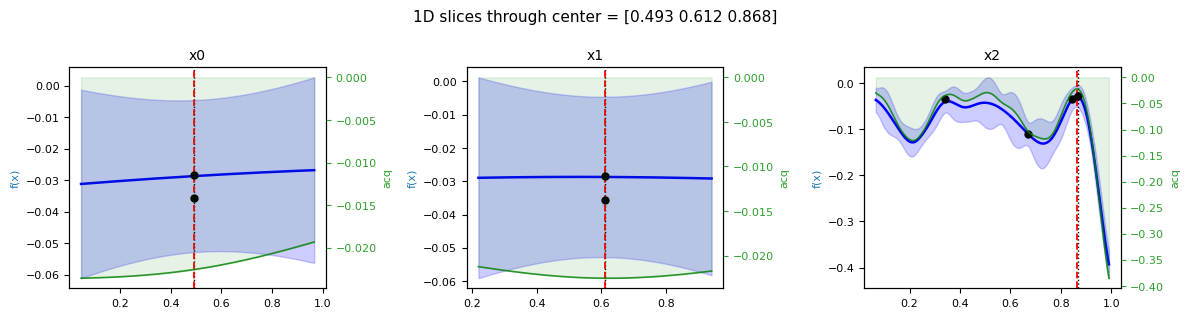

In [37]:
plot_nd_slices(
    X, y, bounds, gp,
    acquisition_fn=ucb_acquisition,
    x_next=x_next,
    acq_kwargs={"kappa": KAPPA, "maximize": True},
)
plt.show()

## Sanity-check the surrogate: leave-one-out calibration

Refitting once per observation, holding it out and predicting it from the rest. This matters more here than in 1D/2D, since we can't just look at the fitted surface and eyeball it.

At this many points the thing to read is whether the error bars cover the diagonal, not how tight the correlation is. Worth watching the one strong outlier (`y = −0.399` against a median around −0.10) — if the GP can't predict it when held out that's expected rather than alarming, but it does mean the surrogate is weak wherever that point sits.

[fitting: leave-one-out calibration] 38 warnings held back, 3 distinct:
    19 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
    18 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06


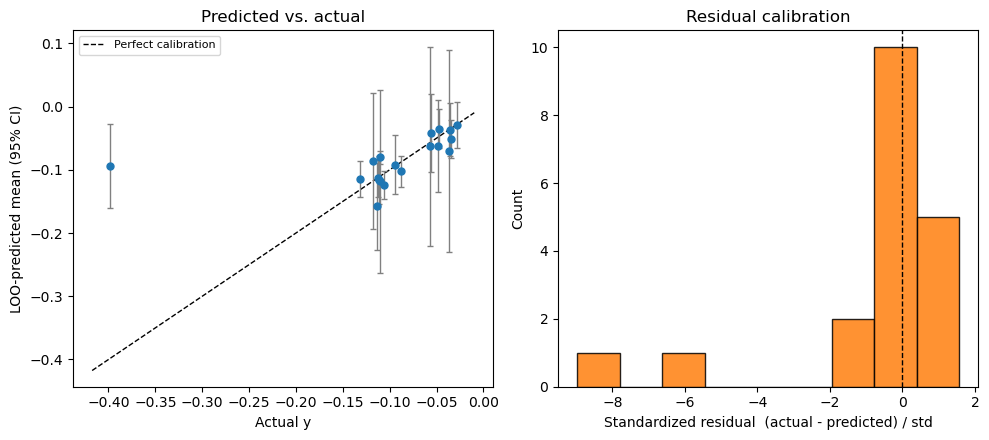

points inside their own 95% LOO interval: 17/19


In [38]:
with fitting("leave-one-out calibration"):
    pred_mean, pred_std = loo_predictions(X, y, bounds,
                                          gp_kwargs={"n_restarts_optimizer": 20})

plot_loo_calibration(y, pred_mean, pred_std)
plt.show()

within = np.abs(y - pred_mean) <= 1.96 * pred_std
print(f"points inside their own 95% LOO interval: {within.sum()}/{len(y)}")

## Iteration diagnostics

Replaying the ordered observations to reconstruct the acquisition value, GP hyperparameters and domain-wide uncertainty at each past proposal.

All three collected points were proposed with `max_variance`, so the replay uses it too and the `acq_value` column reads as "how uncertain was the model there beforehand". From next week the history is mixed and no single setting reconstructs every row faithfully.

Two caveats that still apply. Row order has to be true chronological order. And `domain_mean_std` is the mean uncertainty over *this week's* bounds — the observed bounding box, not the padded box — so those numbers aren't comparable against a week that used different bounds.

`plot_bo_diagnostics` is skipped because it hard-codes a 2D scatter panel. The individual trend plots below are dimension-agnostic and gated until there are enough completed iterations to read a trend.

[fitting: iteration-diagnostics replay (max_variance, as history was made)] 8 warnings held back, 2 distinct:
     4 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
     4 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
Best y so far: -0.028331549686210305
completed iterations beyond the initial batch: 4


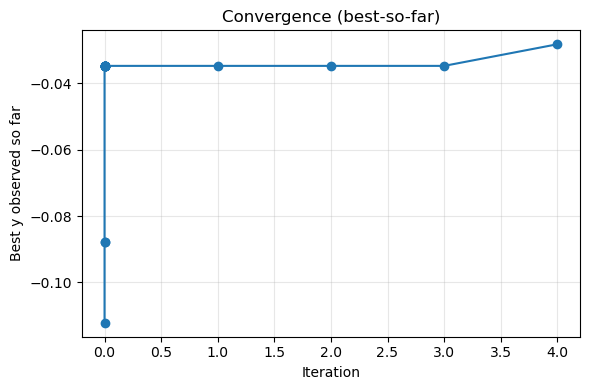

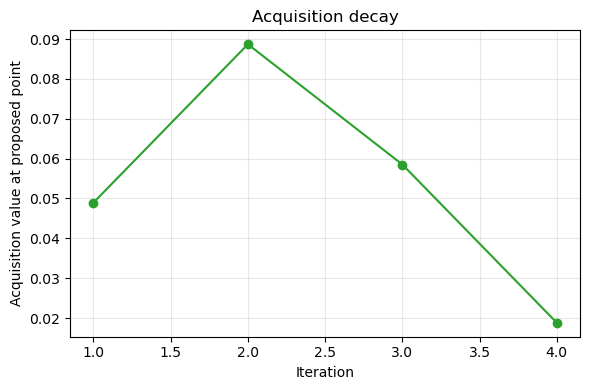

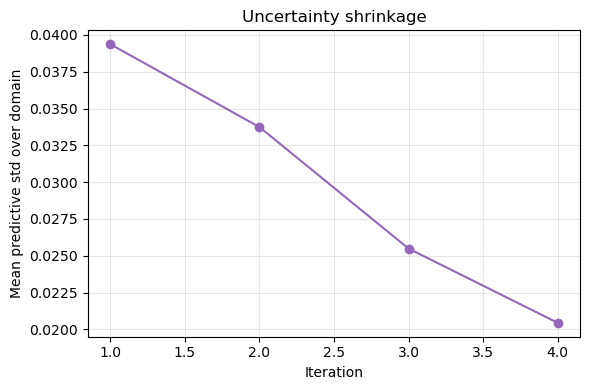

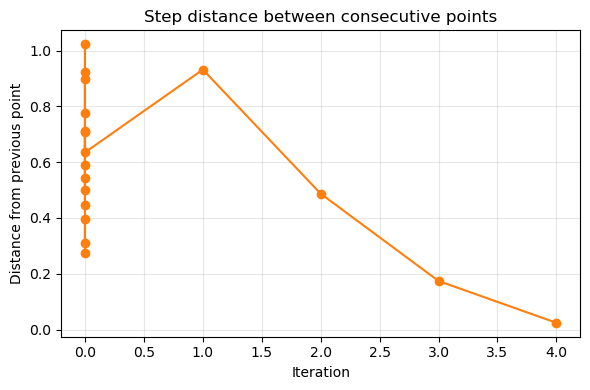

In [39]:
# Fitting first, so the warnings can't split the output.
#
# This deliberately replays with max_variance rather than this week's ucb: all
# three collected points were max_variance proposals, and the replay should use
# what actually chose each point. Once a ucb proposal is recorded the history is
# mixed and no single setting reconstructs every row.
with fitting("iteration-diagnostics replay (max_variance, as history was made)"):
    history = compute_iteration_diagnostics(X, y, bounds, n_initial=n_initial,
                                            acquisition="max_variance", maximize=True)

print("Best y so far:", np.nanmax(history["y"]))
print("completed iterations beyond the initial batch:", len(new_y))

if len(new_y) >= 3:
    for plot_fn in (plot_convergence, plot_acquisition_decay,
                    plot_uncertainty_shrinkage, plot_step_distance):
        plot_fn(history)
        plt.show()
else:
    print(f"\nOnly {len(new_y)} completed iteration(s) -- need at least 3 for the trend")
    print("plots to say anything. Skipping them; the raw fields are below.")

## Raw diagnostic fields

In [40]:
print("y:", history["y"])
print("\niteration:", history["iteration"])
print("\nacq_value (NaN = initial batch; see the caveat above):", history["acq_value"])
print("\ndomain_mean_std:", history["domain_mean_std"])

y: [-0.1121222  -0.08796286 -0.11141465 -0.03483531 -0.04800758 -0.11062091
 -0.39892551 -0.11386851 -0.13146061 -0.09418956 -0.04694741 -0.10596504
 -0.11804826 -0.03637783 -0.05675837 -0.05641777 -0.11005965 -0.03556165
 -0.02833155]

iteration: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 2. 3. 4.]

acq_value (NaN = initial batch; see the caveat above): [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan 0.04895412 0.08871425 0.05852824
 0.01879798]

domain_mean_std: [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan 0.03936494 0.03374035 0.02549062
 0.02045181]


In [41]:
# My proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision too. I submit the 6-dp string; the store keeps 6 dp as well,
# which is what actually gets evaluated.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))

0.492581-0.611593-0.863526

full precision (use for next week's new_X):
0.49258141463713434-0.6115931882759961-0.8635262140243503


In [42]:
# I record this week's proposal in the weekly store. This rewrites inputs.csv
# rather than appending, so re-running the notebook cannot double-record. I
# submit the 6-dp string printed above -- it is the same value written here.
save_proposal(3, new_X, x_next)


wrote weekly_data/function_3/inputs.csv: 5 row(s) (4 resulted + 1 proposal)
  proposal row: 0.49258141463713434-0.6115931882759961-0.8635262140243503


'weekly_data/function_3/inputs.csv'